In [ ]:
import cv2
import matplotlib.pyplot as plt

import pandas as pd
import numpy as np
import os
from utils.nms import postprocess_predictions

### Image size and Yolo Grid

Original Frame shape: (540, 960, 3)
YOLO Input Frame shape: (224, 224, 3)


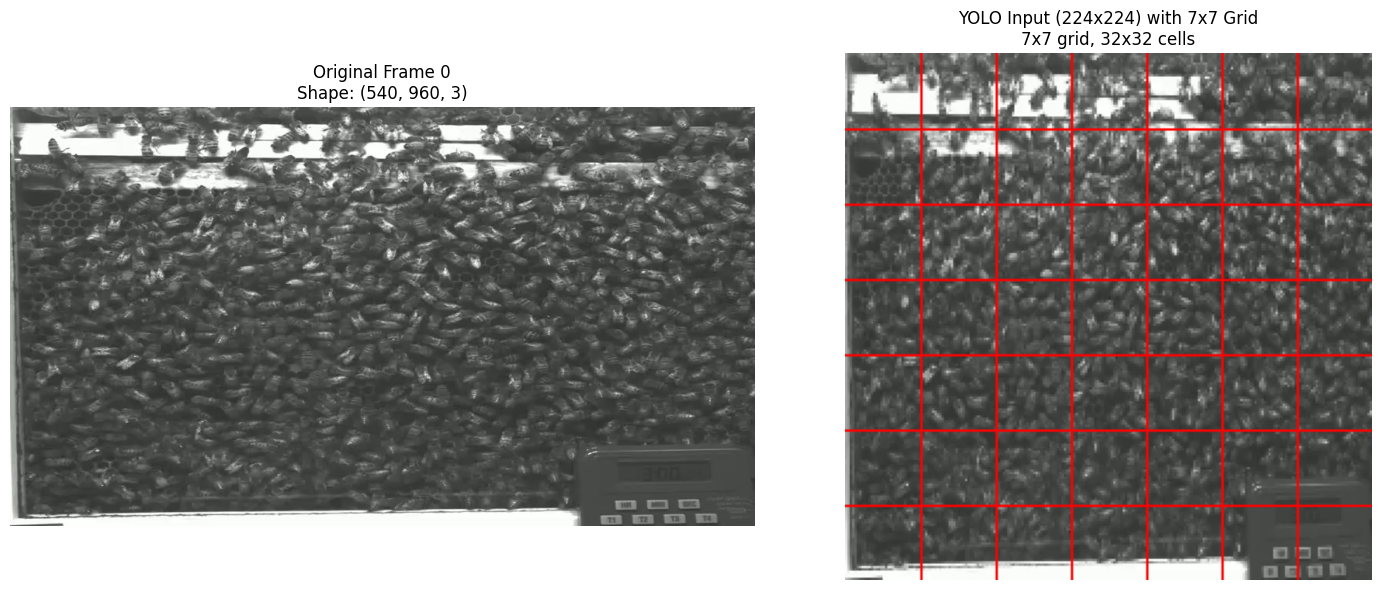

YOLO Grid: 7x7
Cell size: 32x32 pixels
Each cell covers: 0.143 of image width/height


In [4]:
def visualize_single_frame_with_yolo_grid(video_path, frame_number=0):
    # Open the video file
    cap = cv2.VideoCapture(video_path)
    
    # Check if video opened successfully
    if not cap.isOpened():
        print(f"Error: Could not open video {video_path}")
        return
    
    # Set the frame position
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_number)
    
    # Read the frame
    ret, frame = cap.read()
    
    if ret:
        # Convert BGR to RGB for matplotlib
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        print(f'Original Frame shape: {frame_rgb.shape}')
        
        # Resize to YOLO input size
        frame_resized = cv2.resize(frame_rgb, (224, 224))
        print(f'YOLO Input Frame shape: {frame_resized.shape}')
        
        # Create a copy to draw grid on
        frame_with_grid = frame_resized.copy()
        
        # YOLO grid parameters
        grid_size = 7
    
        cell_size = 224 // grid_size  # 32 pixels per cell
        
        # Draw grid lines
        for i in range(1, grid_size):
            # Vertical lines
            cv2.line(frame_with_grid, (i * cell_size, 0), (i * cell_size, 224), (255, 0, 0), 1)
            # Horizontal lines
            cv2.line(frame_with_grid, (0, i * cell_size), (224, i * cell_size), (255, 0, 0), 1)
        
        # Display both images
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
        
        # Original frame
        ax1.imshow(frame_rgb)
        ax1.set_title(f"Original Frame {frame_number}\nShape: {frame_rgb.shape}")
        ax1.axis('off')
        
        # Resized frame with YOLO grid
        ax2.imshow(frame_with_grid)
        ax2.set_title(f"YOLO Input (224x224) with 7x7 Grid\n{grid_size}x{grid_size} grid, {cell_size}x{cell_size} cells")
        ax2.axis('off')
        
        plt.tight_layout()
        plt.show()
        
        print(f"YOLO Grid: {grid_size}x{grid_size}")
        print(f"Cell size: {cell_size}x{cell_size} pixels")
        print(f"Each cell covers: {cell_size/224:.3f} of image width/height")
        
    else:
        print(f"Error: Could not read frame {frame_number}")
    
    cap.release()

# Usage with grid visualization
video_path = "/home/prajna/multiscale_wdd/data/videos/Capture_2025-04-29_14-59-11-1-00.00.01.000-00.02.00.688_downsampled_95.mp4"
visualize_single_frame_with_yolo_grid(video_path, frame_number=0)